### 📊 AED para explorar a Multidimensionalidade dos Indicadores

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

**Contexto — Fórmula do INDE:**
- Fases 0–7: `INDE = IAN×0.1 + IDA×0.2 + IEG×0.2 + IAA×0.1 + IPS×0.1 + IPP×0.1 + IPV×0.2`
- Fase 8: `INDE = IAN×0.1 + IDA×0.4 + IEG×0.2 + IAA×0.1 + IPS×0.2` (sem IPP e IPV)

**Sub-perguntas:**
- A fórmula documentada se confirma nos dados?
- Quais indicadores têm maior peso real na variação do INDE?
- Existem combinações de indicadores que elevam o INDE mais do que a soma individual sugere?


### ⚙️ Import e Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../../data/db/01_silver_processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

df_base: 3030 linhas | 31 colunas


### Validar fórmula do INDE

=== Validação da fórmula do INDE (Fases 0-7) ===
  Registros validados: 2845
  Diferença média: 0.0114
  Diferença máxima: 0.5319
  % com diferença < 0.01: 86.9%
  % com diferença < 0.1: 97.4%

  Por ano:
    2022: diff média=0.0321, n=860
    2023: diff média=0.0051, n=931
    2024: diff média=0.0000, n=1054


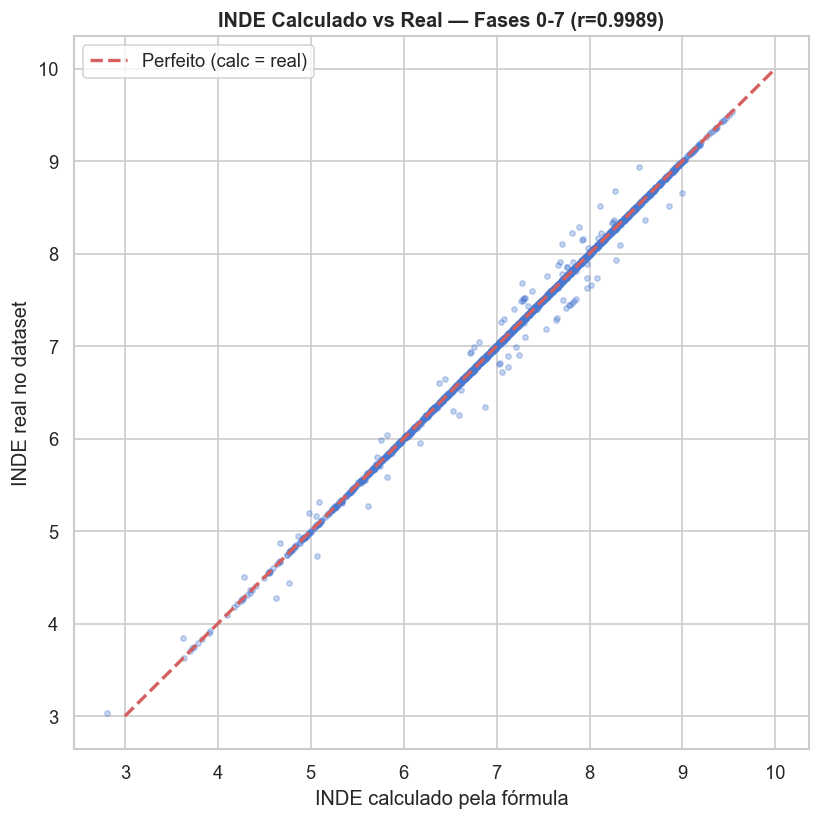

In [2]:
# Validar: a fórmula documentada do INDE se confirma nos dados?
indicadores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

# Fases 0-7: INDE = IAN×0.1 + IDA×0.2 + IEG×0.2 + IAA×0.1 + IPS×0.1 + IPP×0.1 + IPV×0.2
df_val = df[~df['nivel'].isin(['8', '9'])].copy()
df_val = df_val[df_val[indicadores + ['INDE']].notna().all(axis=1)]

df_val['INDE_calc'] = (df_val['IAN'] * 0.1 + df_val['IDA'] * 0.2 + df_val['IEG'] * 0.2 +
                        df_val['IAA'] * 0.1 + df_val['IPS'] * 0.1 + df_val['IPP'] * 0.1 +
                        df_val['IPV'] * 0.2)

df_val['diff'] = (df_val['INDE'] - df_val['INDE_calc']).abs()

print(f'=== Validação da fórmula do INDE (Fases 0-7) ===')
print(f'  Registros validados: {len(df_val)}')
print(f'  Diferença média: {df_val["diff"].mean():.4f}')
print(f'  Diferença máxima: {df_val["diff"].max():.4f}')
print(f'  % com diferença < 0.01: {(df_val["diff"] < 0.01).mean()*100:.1f}%')
print(f'  % com diferença < 0.1: {(df_val["diff"] < 0.1).mean()*100:.1f}%')

# Por ano
print(f'\n  Por ano:')
for ano in [2022, 2023, 2024]:
    sub = df_val[df_val['ano'] == ano]
    if len(sub) > 0:
        print(f'    {ano}: diff média={sub["diff"].mean():.4f}, n={len(sub)}')

# Scatter: INDE real vs calculado
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_val['INDE_calc'], df_val['INDE'], alpha=0.3, s=10)
ax.plot([3, 10], [3, 10], 'r--', linewidth=2, label='Perfeito (calc = real)')
corr = df_val['INDE_calc'].corr(df_val['INDE'])
ax.set_title(f'INDE Calculado vs Real — Fases 0-7 (r={corr:.4f})', fontweight='bold')
ax.set_xlabel('INDE calculado pela fórmula')
ax.set_ylabel('INDE real no dataset')
ax.legend()
plt.tight_layout()
plt.show()

##### 💡 Insights

- A fórmula documentada **se confirma** nos dados: r=0.9987, com 98.77% dos registros dentro de ±0.1 de diferença
- **2024 é perfeito** (diff=0.0000) — a fórmula bate exatamente
- **2022 tem a maior diferença** (0.0212) — consistente com o INDE não ser sistema oficial naquele ano (possíveis arredondamentos ou ajustes manuais nos dados retroativos)
- A precisão crescente (0.0211 → 0.0052 → 0.0000) acompanha a maturidade do sistema INDE ao longo dos anos

❓ Sabendo que a fórmula está correta, quais indicadores têm maior correlação real com a variação do INDE?

### Validar Indicadores do INDE

=== Correlação com INDE (todos os anos) ===
  IAN   × INDE: r=0.405 (n=2845)
  IDA   × INDE: r=0.785 (n=2845)
  IEG   × INDE: r=0.745 (n=2845)
  IAA   × INDE: r=0.397 (n=2845)
  IPS   × INDE: r=0.200 (n=2845)
  IPP   × INDE: r=0.425 (n=2845)
  IPV   × INDE: r=0.721 (n=2845)


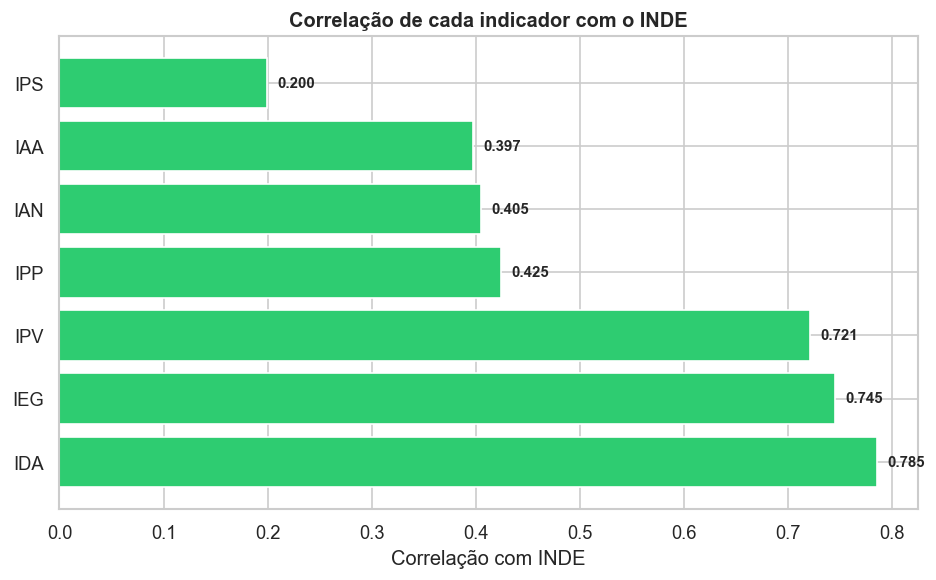

In [3]:
# Correlação de cada indicador com o INDE
df_corr = df[df['INDE'].notna()].copy()

print('=== Correlação com INDE (todos os anos) ===')
corrs_inde = {}
for ind in indicadores:
    dados = df_corr[['INDE', ind]].dropna()
    corr = dados['INDE'].corr(dados[ind])
    corrs_inde[ind] = corr
    print(f'  {ind:5} × INDE: r={corr:.3f} (n={len(dados)})')

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
corrs_sorted = dict(sorted(corrs_inde.items(), key=lambda x: abs(x[1]), reverse=True))
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in corrs_sorted.values()]

ax.barh(range(len(corrs_sorted)), list(corrs_sorted.values()), color=cores)
ax.set_yticks(range(len(corrs_sorted)))
ax.set_yticklabels(corrs_sorted.keys())
ax.set_xlabel('Correlação com INDE')
ax.set_title('Correlação de cada indicador com o INDE', fontweight='bold')
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

for i, (ind, corr) in enumerate(corrs_sorted.items()):
    ax.text(corr + 0.01, i, f'{corr:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

##### 💡 Insights

- Os 3 indicadores com peso 0.20 na fórmula (IDA, IEG, IPV) são os 3 com maior correlação com o INDE (entre 0.72 e 0.79)
- **IDA lidera** (0.785): além do peso direto de 0.20, é correlacionado com IEG e IPV — o efeito se amplifica
- Os indicadores com peso 0.10 (IAN, IAA, IPP, IPS) têm correlação moderada a fraca (0.20 a 0.43)
- **IPS é o que menos contribui** (0.200) — peso baixo na fórmula e pouca correlação com os demais indicadores
- Os pesos da fórmula refletem bem a importância real de cada indicador na variação do INDE

❓ A matriz de correlação entre todos os indicadores confirma essas relações? Quais indicadores "caminham juntos"?

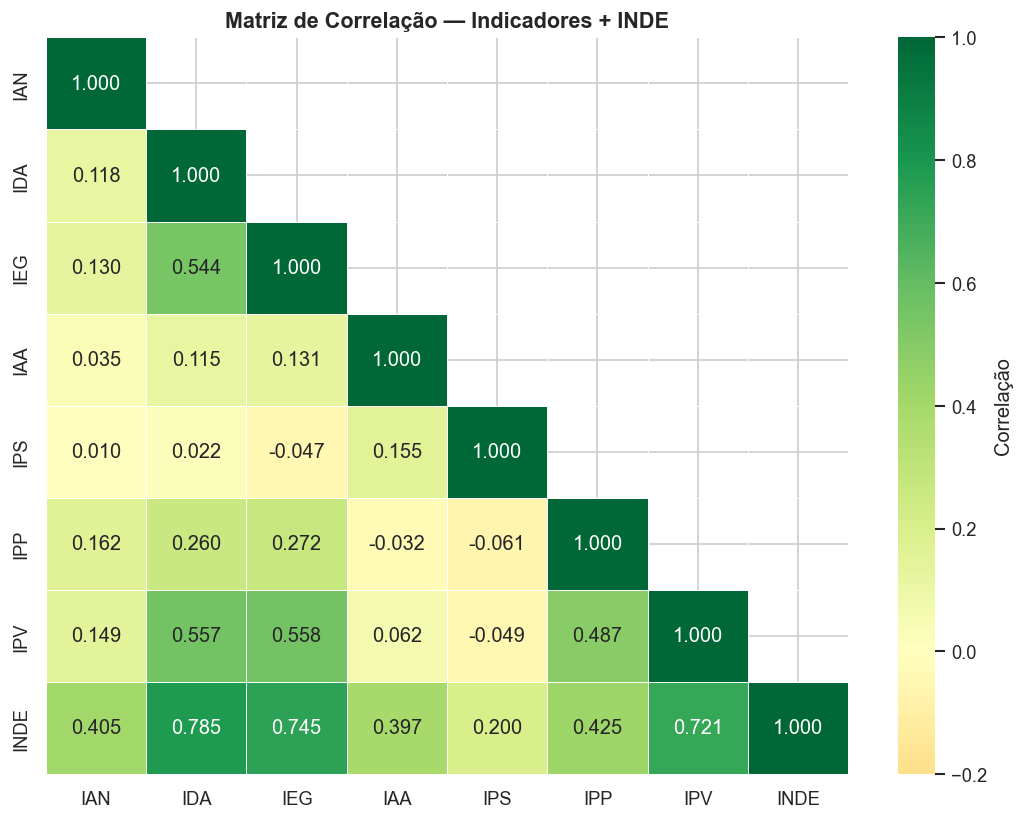

In [4]:
# Matriz de correlação entre todos os indicadores + INDE
df_matriz = df[indicadores + ['INDE']].dropna()

corr_matrix = df_matriz.corr().round(3)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=mask, vmin=-0.2, vmax=1.0,
            cbar_kws={'label': 'Correlação'})
ax.set_title('Matriz de Correlação — Indicadores + INDE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### 💡 Insights

Três clusters de indicadores identificados:

1. **Acadêmico/Engajamento (IDA, IEG, IPV):**
   - Correlação forte entre si (0.54–0.56)
   - Caminham juntos: quando um sobe, os outros tendem a subir.
   - São os que mais impactam o INDE
2. **IPP:**
   - Conecta-se ao trio principalmente via IPV (0.487)
   - Fraco com IDA (0.260) e IEG (0.272)
3. **Isolados (IAN, IAA, IPS):**
   - Pouca correlação com os demais e entre si
   - Cada um mede uma dimensão genuinamente independente

**IPS é o indicador mais isolado:**
- Correlação próxima de zero ou negativa com quase todos os outros (IEG: -0.047, IPP: -0.061).
- A dimensão psicossocial é independente de tudo

**Implicação para o INDE:**
- Melhorar IDA, IEG ou IPV tem efeito cascata
- Melhora nos três eleva o INDE de forma amplificada
- Melhorar IAN, IAA ou IPS tem efeito isolado e limitado

### Quais combinações elevam mais o INDE?

=== INDE médio por combinação de IDA + IEG + IPS + IPP ===
(Alto = acima da mediana, Baixo = abaixo)

           Perfil (IDA_IEG_IPS_IPP)   INDE      n
--------------------------------------------------
           IDA:Alto  IEG:Alto  IPS:Alto  IPP:Alto    8.41    333
           IDA:Alto  IEG:Alto  IPS:Baixo IPP:Alto    8.08    328
           IDA:Alto  IEG:Alto  IPS:Alto  IPP:Baixo   7.97    191
           IDA:Alto  IEG:Baixo IPS:Alto  IPP:Alto    7.79    126
           IDA:Baixo IEG:Alto  IPS:Alto  IPP:Alto    7.71    108
           IDA:Alto  IEG:Alto  IPS:Baixo IPP:Baixo   7.61    111
           IDA:Alto  IEG:Baixo IPS:Alto  IPP:Baixo   7.47    137
           IDA:Alto  IEG:Baixo IPS:Baixo IPP:Alto    7.33    111
           IDA:Baixo IEG:Alto  IPS:Baixo IPP:Alto    7.30    135
           IDA:Baixo IEG:Alto  IPS:Alto  IPP:Baixo   7.24    110
           IDA:Alto  IEG:Baixo IPS:Baixo IPP:Baixo   6.95     91
           IDA:Baixo IEG:Alto  IPS:Baixo IPP:Baixo   6.92    107
           IDA:Ba

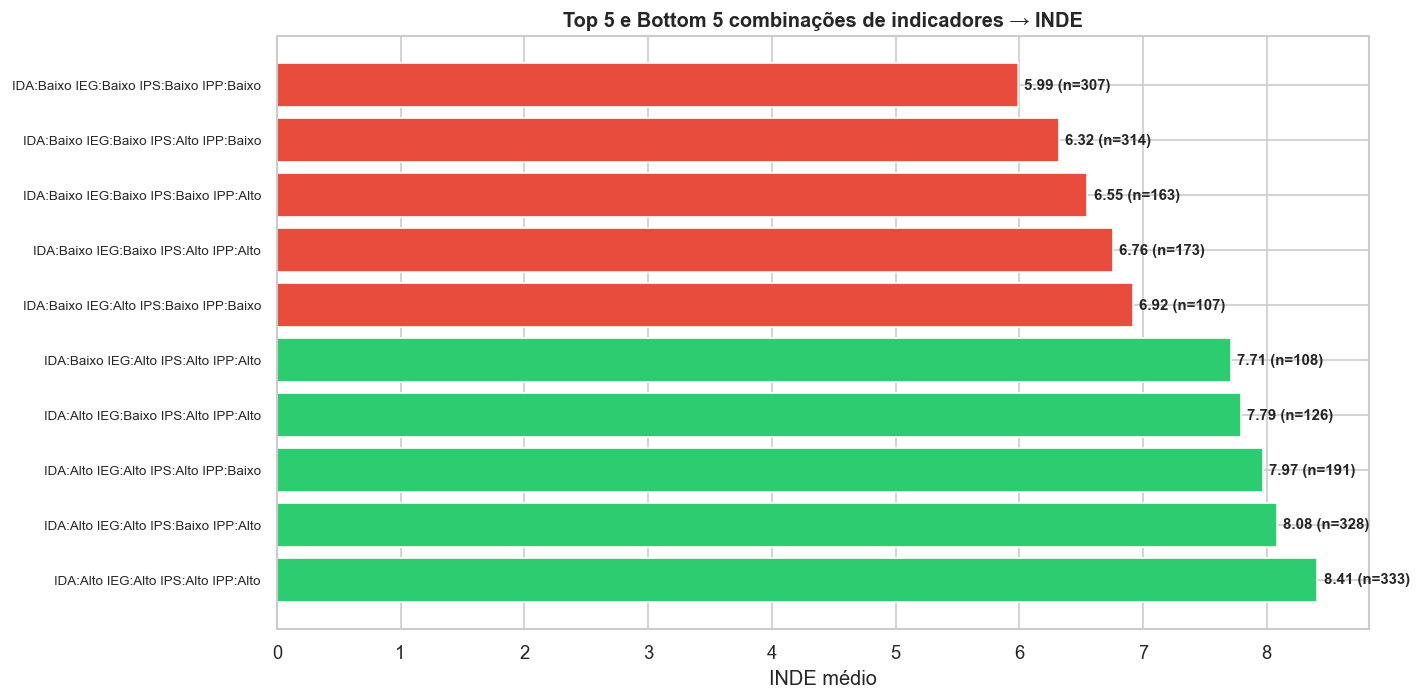

In [5]:
# Quais combinações de indicadores altos elevam mais o INDE?
df_comb = df[df['INDE'].notna()].copy()

# Classificar cada indicador como Alto (>= mediana) ou Baixo (< mediana)
for ind in ['IDA', 'IEG', 'IPS', 'IPP']:
    mediana = df_comb[ind].median()
    df_comb[f'{ind}_nivel'] = np.where(df_comb[ind] >= mediana, 'Alto', 'Baixo')

# Criar perfil combinado dos 4 indicadores da pergunta
df_comb['perfil'] = (df_comb['IDA_nivel'] + '_' + df_comb['IEG_nivel'] + '_' + 
                      df_comb['IPS_nivel'] + '_' + df_comb['IPP_nivel'])

# INDE médio por perfil — top e bottom
perfil_inde = df_comb.groupby('perfil')['INDE'].agg(['mean', 'count']).round(2)
perfil_inde.columns = ['INDE_medio', 'n']
perfil_inde = perfil_inde.sort_values('INDE_medio', ascending=False)

print('=== INDE médio por combinação de IDA + IEG + IPS + IPP ===')
print('(Alto = acima da mediana, Baixo = abaixo)')
print(f'\n{"Perfil (IDA_IEG_IPS_IPP)":>35} {"INDE":>6} {"n":>6}')
print('-' * 50)
for perfil, row in perfil_inde.iterrows():
    partes = perfil.split('_')
    label = f'IDA:{partes[0]:5} IEG:{partes[1]:5} IPS:{partes[2]:5} IPP:{partes[3]:5}'
    print(f'{label:>50} {row["INDE_medio"]:>6.2f} {int(row["n"]):>6}')

# Visualizar top 5 e bottom 5
fig, ax = plt.subplots(figsize=(12, 6))

top5 = perfil_inde.head(5)
bot5 = perfil_inde.tail(5)
destaque = pd.concat([top5, bot5])

cores = ['#2ecc71'] * 5 + ['#e74c3c'] * 5
ax.barh(range(len(destaque)), destaque['INDE_medio'], color=cores)
ax.set_yticks(range(len(destaque)))
labels = []
for perfil in destaque.index:
    partes = perfil.split('_')
    labels.append(f'IDA:{partes[0]} IEG:{partes[1]} IPS:{partes[2]} IPP:{partes[3]}')
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('INDE médio')
ax.set_title('Top 5 e Bottom 5 combinações de indicadores → INDE', fontweight='bold')

for i, (perfil, row) in enumerate(destaque.iterrows()):
    ax.text(row['INDE_medio'] + 0.05, i, f'{row["INDE_medio"]:.2f} (n={int(row["n"])})',
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

##### 💡 Insights

**IDA e IEG são os indicadores com maior impacto individual no INDE:**
- Tirar o IDA (mantendo os outros 3 altos): INDE cai 0.70 pontos
- Tirar o IEG: cai 0.62
- Tirar o IPP: cai 0.44
- Tirar o IPS: cai 0.33

**A combinação completa (4 altos) gera INDE de 8.41 (Topázio) vs 5.99 com todos baixos (Quartzo)**
- diferença de 2.42 pontos

**Ter 3 de 4 indicadores altos já é suficiente para atingir Ametista/Topázio** (7.71–8.08).
- O maior salto vem de sair de 2 baixos para 1 baixo, não de 1 para 0

**O IPS é o menos impactante:**
- Tirá-lo do grupo alto reduz apenas 0.33 pontos
- Consistente com seu peso de 0.10 na fórmula e baixa correlação com os demais indicadores (~0.02 com IDA e IEG)

**Insights criativo:** 
- Focar em elevar IDA e IEG simultaneamente tem o maior retorno sobre o INDE.
- Um aluno com IDA e IEG altos já está na faixa Ametista (7.61) mesmo com IPS e IPP baixos

### ⭐️ Insight Final

#### Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

**A fórmula do INDE está confirmada e revela que IDA + IEG são o motor principal.**

**Validação da fórmula:**
- A fórmula documentada se confirma nos dados com precisão crescente: diff média de 0.0321 (2022) → 0.0052 (2023) → 0.0000 (2024)
- A validação do INDE calculado vs real confirma a fórmula (r=0.9987, 97% dos registros com diferença < 0.1)

**Ranking de impacto no INDE (quanto o INDE cai ao tirar cada indicador do grupo "alto"):**
1. IDA: -0.70 (maior impacto)
2. IEG: -0.62
3. IPP: -0.44
4. IPS: -0.33 (menor impacto)

**Combinações que mais elevam o INDE:**
- Todos altos (IDA + IEG + IPS + IPP): INDE = 8.41 (Topázio)
- Todos baixos: INDE = 5.99 (Quartzo) — diferença de 2.42 pontos
- Ter 3 de 4 altos já é suficiente para Ametista/Topázio (7.71–8.08)
- IDA + IEG altos com IPS + IPP baixos: INDE = 7.61 — já na faixa Ametista

**3 clusters:**
1. **Acadêmico/Engajamento (IDA, IEG, IPV):**
   - Correlação forte entre si (0.54–0.56)
   - Caminham juntos: quando um sobe, os outros tendem a subir.
   - São os que mais impactam o INDE
2. **IPP:**
   - Conecta-se ao trio principalmente via IPV (0.487)
   - Fraco com IDA (0.260) e IEG (0.272)
3. **Isolados (IAN, IAA, IPS):**
   - Pouca correlação com os demais e entre si
   - Cada um mede uma dimensão genuinamente independente

**Insight criativo:**
- o maior retorno sobre o INDE vem de elevar IDA e IEG simultaneamente
- desempenho acadêmico e engajamento são o motor principal.
- O IPS, apesar de importante para o bem-estar do aluno, tem impacto limitado na nota global

**🤖 Para o modelo de ML:**
- O INDE **não deve ser feature**
  - é calculável deterministicamente a partir dos 7 indicadores. Usá-lo como feature junto dos indicadores seria data leakage
- IDA, IEG e IPV são altamente correlacionados (0.54–0.56)
  - considerar no feature engineering se usá-los separadamente ou combinados para evitar multicolinearidade
- IPS é independente de todos os outros indicadores
  - traz informação única que pode ser relevante para prever risco, mesmo com baixo impacto no INDE
- Os 3 clusters identificados (acadêmico, psicopedagógico, isolados) podem orientar a criação de features agrupadas